<div align="center">
  <a href="https://pageindex.ai/developer">
    <img src="https://github.com/user-attachments/assets/bae02956-6c4e-4a0b-adea-257b0be4aaa1" width="100%" alt="PageIndex — Vectorless, Reasoning-based RAG">
  </a>
  <p>
    <a href="https://pageindex.ai/developer">🌐 Website</a> &nbsp; · &nbsp;
    <a href="https://developer.pageindex.ai/">☁️ Cloud</a> &nbsp; · &nbsp;
    <a href="https://docs.pageindex.ai/">📖 Docs</a> &nbsp; · &nbsp;
    <a href="https://github.com/VectifyAI/PageIndex">⭐ GitHub</a> &nbsp; · &nbsp;
    <a href="https://pageindex.ai/contact">✉️ Contact</a>
  </p>
</div>

---

# PageIndex Citations & Source Highlighting

**Trace an answer back to the exact region on the page.**

A useful citation lets readers check the evidence behind an answer. This notebook demonstrates how to turn **PageIndex Cloud’s block-level citations** into highlighted source regions in the original document.

We ask a question about revenue in a financial report, resolve the citations with the SDK to get each source’s document ID, page, and bounding box. We then fetch the full-page image and highlight the cited region so readers can compare the answer with the original context.

1. **Ask with citations** — Stream an answer with references to its supporting document blocks.
2. **Resolve the references** — Let the SDK parse citations and fetch their source blocks.
3. **Highlight the sources** — Display each cited region on its source page.

**Before you start:** Have your OpenAI API key ready. This demo uses an existing document on PageIndex Cloud with the supplied demo access key. Highlighting requires a document with block-level layout data and a full-page image available.


## 01 · Set up

Install the latest PageIndex SDK for citation resolution, page images, and highlighting. Requests downloads the image, and Pillow supports the SDK’s image helper.


In [ ]:
!pip install -U pageindex requests

### Configure your client

Set your API keys and choose your chat `MODEL`. The client uses PageIndex Cloud to access the document and its layout blocks, and your chosen model to answer the question.


In [ ]:
import os
from pageindex import PageIndexClient

os.environ["PAGEINDEX_API_KEY"]="pageindex_demo_readonly_key"
os.environ["OPENAI_API_KEY"] = "Your OpenAI API key here"

MODEL = "gpt-5.6-luna"  # gpt-5.6-sol / gpt-5.6-terra / gpt-5.6-luna

client = PageIndexClient(
    index="cloud",
    chat=MODEL,
)

## 02 · Ask a question with citations

Ask about revenue in the demo financial report. With `citations=True`, the model is instructed to attach source references to its answer. The stream shows the answer alongside retrieval tool calls.

A block-level reference looks like `<cite doc="report.pdf" page="12" block="p12_text_3"/>`. These attributes connect the answer to a document, a page, and a specific region on that page.


In [8]:
messages = [{"role": "user", "content": "What is the revenue in last year"}]

doc_id = "pi-cmu3rrhyb00280dnsyshkq578"
response = None
for event in client.chat(messages, doc_id=doc_id,
                         stream=True, citations=True, protocol="responses"):
    if event["type"] == "response.output_text.delta":
        print(event["delta"], end="", flush=True)
    elif event["type"] == "response.output_item.done":
        item = event["item"]
        if item.get("type") == "function_call":
            print(f"\n[Tool call] {item['name']}({item.get('arguments', '')})", flush=True)
    elif event["type"] in {"response.completed", "response.incomplete", "response.failed"}:
        response = event["response"]



[Tool call] get_document_structure({"doc_name":"NVIDIA-FY2026-10-K.pdf","folder_id":"cmu3rre91000r0cp4qb90h0fa","part":1})

[Tool call] get_page_content({"doc_name":"NVIDIA-FY2026-10-K.pdf","folder_id":"cmu3rre91000r0cp4qb90h0fa","pages":"37-40"})
NVIDIA’s revenue in the prior fiscal year (fiscal 2025, ended January 26, 2025) was **$130.497 billion**. <cite doc="NVIDIA-FY2026-10-K.pdf" page="37" block="p37_table_6"/>

For comparison, fiscal 2026 revenue was **$215.938 billion**, an increase of 65%. <cite doc="NVIDIA-FY2026-10-K.pdf" page="40" block="p40_table_5"/>

## 03 · Get citation details

Use `client.get_citations(answer_text)` to parse the answer and retrieve its source blocks. Each reference includes `document`, `doc_id`, and `page`, plus `block_id` and `bbox` for resolved block-level citations.

Page-only or unreadable references may have no bounding box; the next step skips these and highlights every reference with a resolved source region. See the [citations documentation](https://docs.pageindex.ai/sdk/chat#citations) for the current SDK interfaces.


In [9]:
# Read only the assistant's answer, excluding tool calls and tool outputs.
answer_text = "\n".join(
    part.get("text", "")
    for item in (response or {}).get("output", [])
    if item.get("type") == "message" and item.get("role") == "assistant"
    for part in item.get("content", [])
    if part.get("type") == "output_text"
)

citations = client.get_citations(answer_text)
citations

[{'document': 'NVIDIA-FY2026-10-K.pdf',
  'doc_id': 'pi-cmu3rrhyb00280dnsyshkq578',
  'page': 37,
  'block_id': 'p37_table_6',
  'bbox': [26, 378, 975, 512],
  'block_type': 'table',
  'text': '|   | Year Ended  |   |   |\n| --- | --- | --- | --- |\n|   |  Jan 25, 2026 | Jan 26, 2025 | Change  |\n|  ($ in millions, except per share data)  |   |   |   |\n|  Revenue | $ 215,938 | $ 130,497 | Up 65%  |\n|  Gross margin | 71.1 % | 75.0 % | -3.9 pts  |\n|  Operating expenses | $ 23,076 | $ 16,405 | Up 41%  |\n|  Operating income | $ 130,387 | $ 81,453 | Up 60%  |\n|  Net income | $ 120,067 | $ 72,880 | Up 65%  |\n|  Net income per diluted share | $ 4.90 | $ 2.94 | Up 67%  |'},
 {'document': 'NVIDIA-FY2026-10-K.pdf',
  'doc_id': 'pi-cmu3rrhyb00280dnsyshkq578',
  'page': 40,
  'block_id': 'p40_table_5',
  'bbox': [26, 401, 978, 506],
  'block_type': 'table',
  'text': '|   | Year Ended  |   |   |   |\n| --- | --- | --- | --- | --- |\n|   |  Jan 25, 2026 | Jan 26, 2025 | $ Change | % Change  |

## 04 · Highlight the cited regions

For each citation with a document ID and bounding box, fetch its page with `client.get_page_image()` and pass the image bytes and `bbox` to `highlight_region()`. Display each highlighted page with its document, page number, and block ID.

References without a resolved source region are skipped. No additional model query is needed.


NVIDIA-FY2026-10-K.pdf · Page 37 · p37_table_6


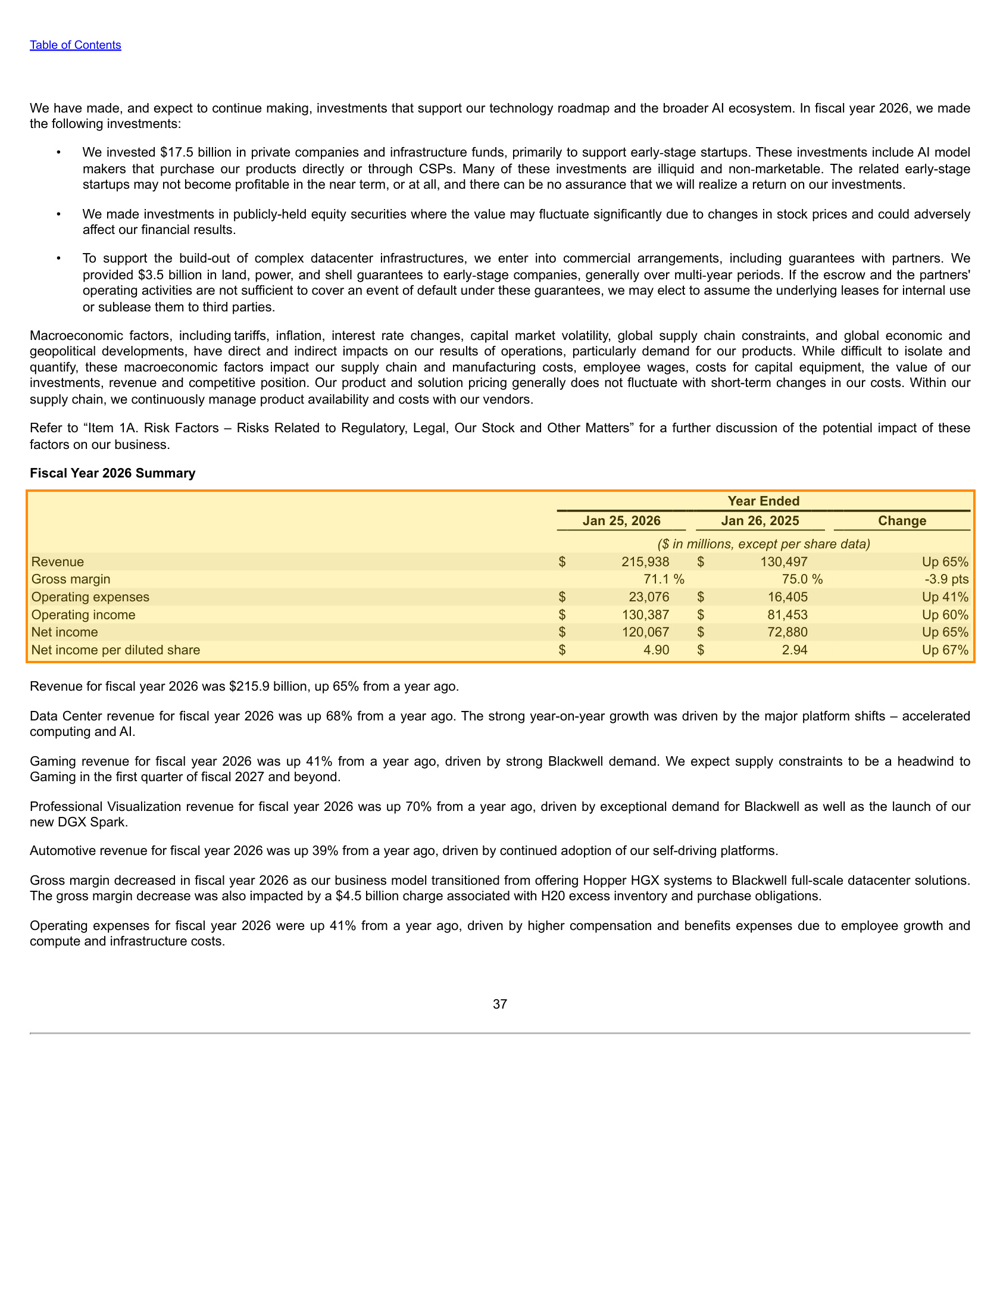

NVIDIA-FY2026-10-K.pdf · Page 40 · p40_table_5


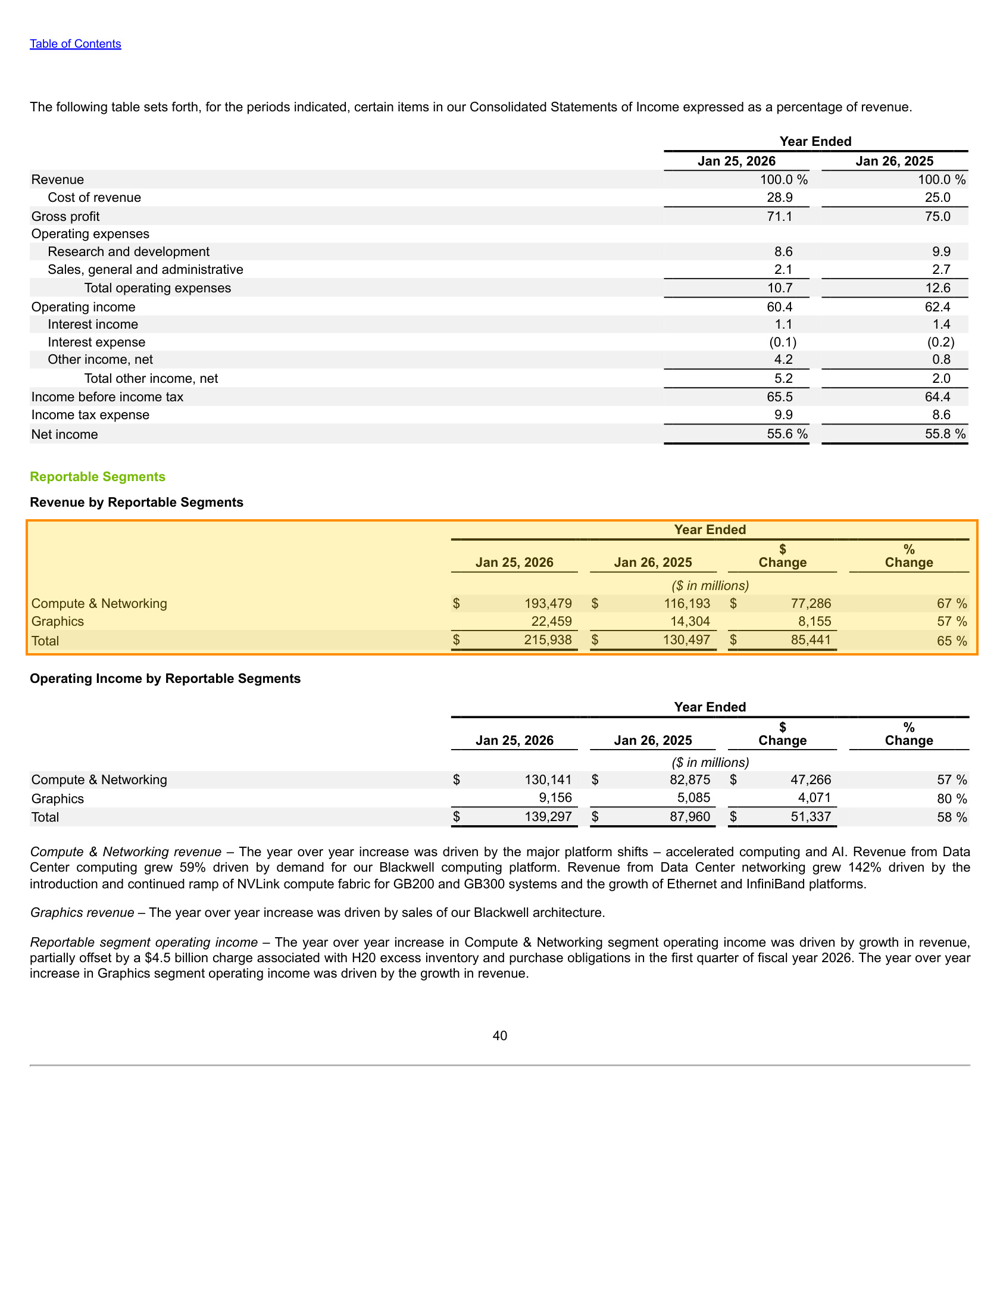

In [10]:
import requests
from IPython.display import display
from pageindex import highlight_region

for citation in citations:
    if not citation.get("doc_id") or not citation.get("bbox"):
        continue

    url = client.get_page_image(citation["doc_id"], citation["page"])
    image_response = requests.get(url, timeout=30)
    image_response.raise_for_status()
    image = highlight_region(image_response.content, citation["bbox"])
    image.thumbnail((1000, 10000))
    print(f"{citation['document']} · Page {citation['page']} · {citation['block_id']}")
    display(image)


## 05 · Review usage & estimated cost (optional)

Inspect the token usage for the answer and estimate its model cost using the rate table below. Resolving citations and drawing highlights do not require additional model calls. This estimate does not include PageIndex Cloud charges.


In [11]:
import json

# Standard USD per 1M tokens: (input, cached input, output).
# Checked 2026-09-17: https://developers.openai.com/api/docs/models/{model}
PRICES = {
    "gpt-5.6-sol": (4.0, 0.4, 20.0),
    "gpt-5.6-terra": (2.0, 0.2, 12.0),
    "gpt-5.6-luna": (0.2, 0.02, 1.2),
}
input_rate, cached_rate, output_rate = PRICES[MODEL]

usage = response.get("usage") if response else None
print("\n\nUsage:", json.dumps(usage, ensure_ascii=False, indent=2))
if response and response.get("status") != "completed":
    print("Response did not complete:", response.get("error") or response.get("incomplete_details"))

if usage:
    details = usage.get("input_tokens_details") or {}
    cached = details.get("cached_tokens", 0) or 0
    written = details.get("cache_write_tokens", 0) or 0
    regular = usage["input_tokens"] - cached - written
    cost = (regular * input_rate + cached * cached_rate + written * input_rate * 1.25
            + usage["output_tokens"] * output_rate) / 1_000_000
    print(f"Estimated model cost at base rates: ${cost:.6f} USD")
    if usage["input_tokens"] > 272_000:
        print("Usage is aggregated across model calls; the estimate excludes possible long-context surcharges.")
else:
    print("No usage returned; unable to estimate cost.")



Usage: {
  "input_tokens": 40202,
  "input_tokens_details": {
    "cached_tokens": 23321,
    "cache_write_tokens": 16872
  },
  "output_tokens": 298,
  "output_tokens_details": {
    "reasoning_tokens": 71
  },
  "total_tokens": 40500
}
Estimated model cost at base rates: $0.005044 USD


---

<div align="center">
  <br>
  <p>
    <a href="https://docs.pageindex.ai/"><b>Upload your documents</b></a>
    &nbsp;&nbsp; · &nbsp;&nbsp;
    <a href="https://docs.pageindex.ai/sdk/agents"><b>Integrate with your agent</b></a>
    &nbsp;&nbsp; · &nbsp;&nbsp;
    <a href="https://github.com/VectifyAI/PageIndex"><b>Star PageIndex on GitHub</b></a>
  </p>
  <br>
  <a href="https://pageindex.ai">
    <img src="https://github.com/user-attachments/assets/e1c677f2-b590-4ffc-859d-e8cc7d794bdf" width="144" height="40" alt="PageIndex">
  </a>
</div>
